In [1]:
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from tqdm import tqdm
import numpy as np

from datasets.bcdata import BCDataDataset, collate_heatmap_points
from datasets.transforms import PointsToLocalizationHeatmap, PointsToCountHeatmap


from visualization import overlay_heatmap
from training import train


from models.models import HybridModel
from models.losses import weighted_sigmoid_mse_from_logits, softplus_mse_from_logits, l1_count_from_density_logits

from utils.debug import print_info


import torch
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [2]:

with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)


data_root = Path(cfg["h200_paths"]["data_root"])
checkpoint_dir = Path(cfg["h200_paths"]["checkpoint_dir"])

print(f"data_root: {data_root}")
print(f"checkpoint_dir: {checkpoint_dir}")

data_root: /raid/datasets/Yeldos/BCData
checkpoint_dir: checkpoints


In [3]:
loc_heatmap_generator = PointsToLocalizationHeatmap(out_hw=(160,160), in_hw=(640,640), sigma=2.0)
count_heatmap_generator = PointsToCountHeatmap(out_hw=(160,160), in_hw=(640,640), sigma=2.0)

dataset = BCDataDataset(root = data_root,
                        split="train",
                        target_loc_transform = loc_heatmap_generator,
                        target_count_transform = count_heatmap_generator)

In [4]:
model = HybridModel()
device = 'cuda'
model.to(device);

In [18]:
model.load_state_dict(torch.load("checkpoints/hybrid_01.pt"))
model.eval()

HybridModel(
  (backbone): ResNet34Backbone(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=

In [19]:
img, loc_heatmap, count_heatmap, pos_pts, neg_pts = dataset[0]
img = img.to(device)
loc_heatmap = loc_heatmap.to(device)
count_heatmap = count_heatmap.to(device)

In [20]:
pos_pts.shape

torch.Size([51, 2])

In [21]:
neg_pts.shape

torch.Size([28, 2])

In [22]:
pred_loc_hm, pred_den_hm, pred_count = model(img.unsqueeze(0))


In [23]:
pred_count

tensor([[-20460696., -21257188.]], device='cuda:0', grad_fn=<CatBackward0>)

In [24]:
pred_loc_hm.shape

torch.Size([1, 2, 160, 160])

In [39]:
pred_den_hm.sum(dim=(2, 3))

tensor([[-20460696., -21257188.]], device='cuda:0', grad_fn=<SumBackward1>)

In [40]:
count_heatmap.sum(dim=(1, 2))

tensor([51., 28.], device='cuda:0')

In [32]:
pred_den_hm.shape

torch.Size([1, 2, 160, 160])

In [33]:
count_heatmap.shape

torch.Size([2, 160, 160])

In [41]:
pred_den_hm

tensor([[[[ -159.5844,  -275.6307,  -334.4218,  ...,  -382.5365,
            -314.5555,  -180.7191],
          [ -277.2904,  -478.5089,  -580.5553,  ...,  -660.7841,
            -543.3201,  -312.3833],
          [ -337.6428,  -582.4856,  -706.4998,  ...,  -797.1057,
            -655.5209,  -377.2089],
          ...,
          [ -361.6596,  -623.4881,  -755.9199,  ..., -1100.5571,
            -901.6799,  -518.2345],
          [ -299.1320,  -515.6890,  -625.2122,  ...,  -904.1396,
            -740.9875,  -426.1136],
          [ -174.0978,  -300.0190,  -363.8606,  ...,  -523.8167,
            -429.1332,  -247.1324]],

         [[ -166.2640,  -286.2411,  -347.5565,  ...,  -397.8026,
            -325.5760,  -186.3083],
          [ -287.0095,  -495.4102,  -601.5941,  ...,  -685.3626,
            -561.8821,  -322.4613],
          [ -349.4616,  -602.9012,  -731.5137,  ...,  -825.6526,
            -677.0475,  -388.8712],
          ...,
          [ -374.6287,  -645.5670,  -782.5119,  ..., -1140.

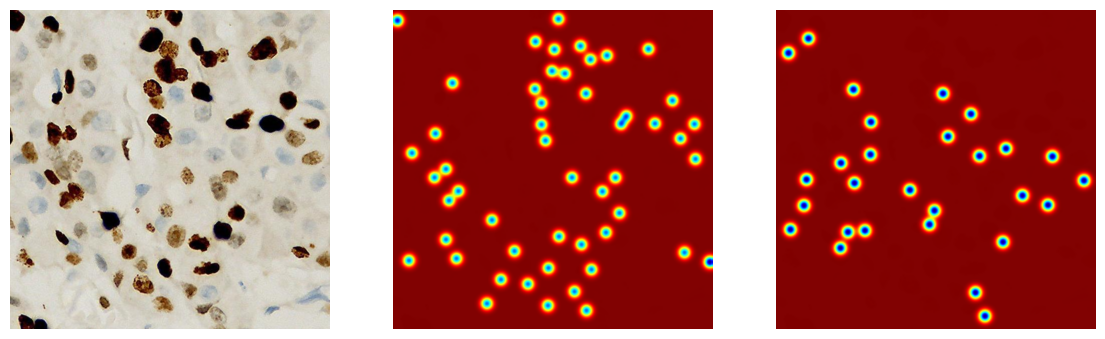

In [31]:
overlay_heatmap(img, count_heatmap, alpha=0.99)


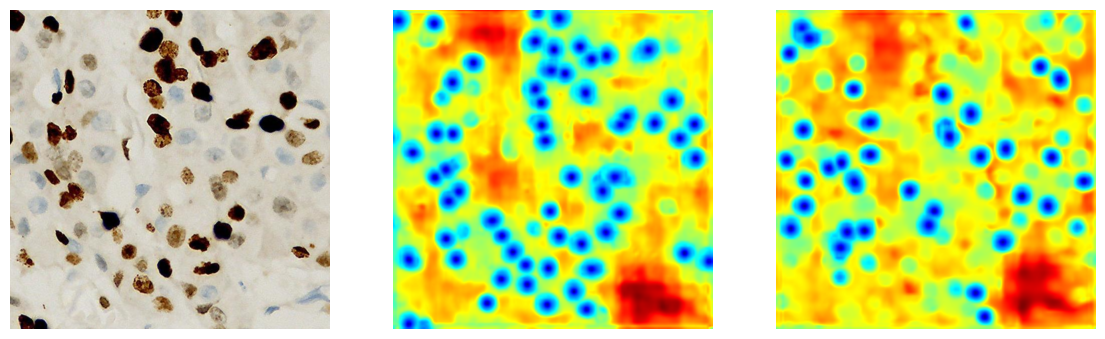

In [29]:
overlay_heatmap(img, pred_loc_hm[0], alpha=0.99)

In [25]:
img.shape

torch.Size([3, 640, 640])